# LIME for ECG Time Series Dataset Example

This notebook demonstrates how to use LIME technique for time series datasets by employing the modules in src.

In [20]:
import sys
# Update the path below according to your project structure
sys.path.append('../src')

In [21]:
import numpy as np
import sys
import os
import src
# 获取当前执行文件的绝对路径
current_file = "E:/Python/LIME-for-Time-Series/notebooks/main.ipynb"
# 计算项目根目录（假设当前文件在项目根目录下）
project_root = os.path.dirname(current_file)
# 拼接 src 目录的绝对路径
src_path = os.path.join(project_root, "src")
# 标准化 Windows 路径（自动处理 \ 和 /）
src_path = os.path.normpath(src_path)
# 将 src 绝对路径插入到搜索路径最前面
if src_path not in sys.path:
    sys.path.insert(0, src_path)


### Loading and Preprocessing the Dataset

In [22]:

from src.data_processing import load_npz_data, format_for_model

In [24]:
from src import data_processing

# --- 修改前 ---
# train_path = './EEG_data/eeg_fpz_cz'

# --- 修改后 (使用绝对路径或更明确的相对路径) ---
import sys
import os
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. 路径与环境配置 ---
# 获取当前 notebook 目录 (E:\Python\LIME-for-Time-Series\notebooks)
current_notebook_dir = os.getcwd()
# 获取项目根目录 (E:\Python\LIME-for-Time-Series)
project_root = os.path.dirname(current_notebook_dir)

# 将 src 加入路径，这样才能导入 data_processing
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 导入你的模块
import src.data_processing as dp

# --- 2. 加载 EEG 数据 ---
# 定位到 EEG_data 下的 eeg_fpz_cz 文件夹
train_path = os.path.join(project_root, 'EEG_data', 'eeg_fpz_cz')

print(f"当前工作目录: {current_notebook_dir}")
print(f"正在尝试从此处加载数据: {train_path}")

if os.path.exists(train_path):
    # 使用 dp 别名调用函数
    X_raw, y_raw = dp.load_npz_data(train_path)

    print("\n原始数据加载完成:")
    print(f"信号特征形状: {X_raw.shape}") # 预期: (样本数, 3000, 1)
    print(f"标签形状: {y_raw.shape}")     # 预期: (样本数,)

    # --- 3. 格式化数据 ---
    # num_classes=5 代表睡眠的 5 个阶段 (W, N1, N2, N3, REM)
    X_data, y_data = dp.format_for_model(X_raw, y_raw, num_classes=5)

    # --- 4. 划分训练集和测试集 ---
    # stratify=y_raw 确保训练集和测试集的睡眠分期比例一致
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_raw
    )

    print("\n数据集划分完成:")
    print(f"训练集形状: {X_train.shape}")
    print(f"测试集形状: {X_test.shape}")
else:
    print(f"错误：找不到路径 {train_path}，请检查文件夹位置。")

当前工作目录: E:\Python\LIME-for-Time-Series\notebooks
正在尝试从此处加载数据: E:\Python\LIME-for-Time-Series\EEG_data\eeg_fpz_cz
正在从 E:\Python\LIME-for-Time-Series\EEG_data\eeg_fpz_cz 加载 38 个文件...

原始数据加载完成:
信号特征形状: (41034, 3000, 1)
标签形状: (41034,)

数据集划分完成:
训练集形状: (32827, 3000, 1)
测试集形状: (8207, 3000, 1)


In [25]:
# --- 旧代码 (ECG DataFrame) ---
# print(ecg_train.info())

# --- 新代码 (EEG Numpy Array) ---
print("Training dataset properties:")
print(f"- X_train shape (Samples, Timesteps, Channels): {X_train.shape}")
print(f"- y_train shape (Samples, Classes): {y_train.shape}")
print(f"- Data type of X_train: {X_train.dtype}")

# 如果你想看标签的具体分布情况（类似于 DataFrame 的统计说明）
import pandas as pd
unique, counts = np.unique(y_raw, return_counts=True)
label_dist = pd.DataFrame({'Stage': unique, 'Count': counts})
print("\nLabel Distribution (Sleep Stages):")
print(label_dist)

Training dataset properties:
- X_train shape (Samples, Timesteps, Channels): (32827, 3000, 1)
- y_train shape (Samples, Classes): (32827, 5)
- Data type of X_train: float32

Label Distribution (Sleep Stages):
   Stage  Count
0      0   7909
1      1   2732
2      2  17365
3      3   5643
4      4   7385


In [26]:
# --- 旧代码 (ECG) ---
# ecg_test.info()
# --- 新代码 (EEG) ---
print("Testing dataset properties:")
# 打印测试集的特征维度和标签维度
print(f"- X_test shape (Samples, Timesteps, Channels): {X_test.shape}")
print(f"- y_test shape (Samples, Classes): {y_test.shape}")
# 验证数据范围内是否有异常值（替代 info() 的非空检查）
print(f"- Any NaN in X_test: {np.isnan(X_test).any()}")
print(f"- Max value in X_test: {np.max(X_test)}")
print(f"- Min value in X_test: {np.min(X_test)}")

Testing dataset properties:
- X_test shape (Samples, Timesteps, Channels): (8207, 3000, 1)
- y_test shape (Samples, Classes): (8207, 5)
- Any NaN in X_test: False
- Max value in X_test: 196.0
- Min value in X_test: -207.6945037841797


In [27]:
# --- 旧代码 (针对 ECG CSV 结构) ---
# ecg_train_x, ecg_train_y = split_data(ecg_train, target_column=0, split=True)

# --- 新代码 (针对 EEG Numpy 结构) ---
# 实际上 load_npz_data 已经帮我们分好了 X 和 y
# 这里的 eeg_train_x 对应 X_train，eeg_train_y 对应 y_train

eeg_train_x = X_train
eeg_train_y = y_train

print("Training features shape:")
# EEG 数据不建议用 head()，因为它是三维数组，直接打印形状和前两个样本的部分数据
print(eeg_train_x.shape)

print("\nFirst 2 samples (first 5 time points of each):")
# 展示前两个样本，前五个时间点的数据
print(eeg_train_x[:2, :5, 0])

print("\nTraining targets (One-hot encoded) for first 2 samples:")
# 展示前两个样本的标签
print(eeg_train_y[:2])

Training features shape:
(32827, 3000, 1)

First 2 samples (first 5 time points of each):
[[26.92381   20.597069  11.2        1.7098901 -0.9882784]
 [ 1.1575092  3.4368742 -4.2778997 23.95116   -6.6449327]]

Training targets (One-hot encoded) for first 2 samples:
[[0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]]


EEG Sleep Stage Distribution (Normalized):
Stage W: 0.1927
Stage N1: 0.0666
Stage N2: 0.4232
Stage N3: 0.1375
Stage REM: 0.1800


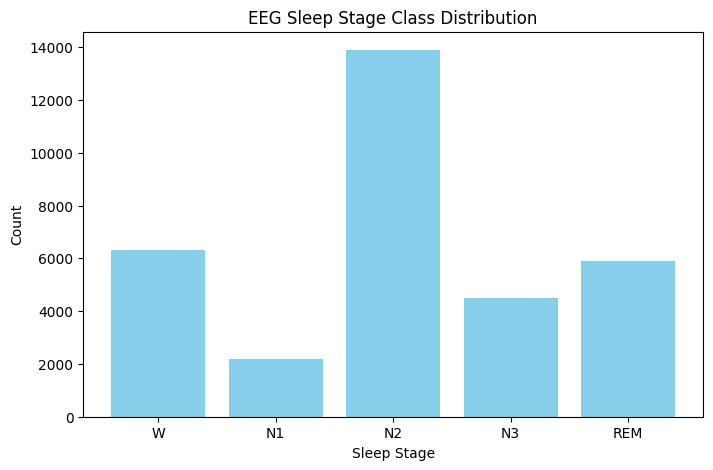

In [29]:
# --- 1. 计算标签分布 (替代 value_counts) ---
# 因为 eeg_train_y 是 One-hot 格式，我们用 np.argmax 转回 0,1,2,3,4 的类别索引
train_labels = np.argmax(y_train, axis=1)

# 使用 np.unique 统计各类别比例
unique, counts = np.unique(train_labels, return_counts=True)
dist = dict(zip(unique, counts / len(train_labels)))

print("EEG Sleep Stage Distribution (Normalized):")
# 映射睡眠阶段名称以便阅读
stage_names = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
for label, proportion in dist.items():
    print(f"Stage {stage_names[label]}: {proportion:.4f}")

# --- 2. 绘图部分 ---
# 如果你想继续使用原来的 plot_class_distribution，需要传入转化后的 Series
# 或者直接在这里写一个简单的绘图逻辑
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar([stage_names[i] for i in unique], counts, color='skyblue')
plt.title("EEG Sleep Stage Class Distribution")
plt.xlabel("Sleep Stage")
plt.ylabel("Count")
plt.show()


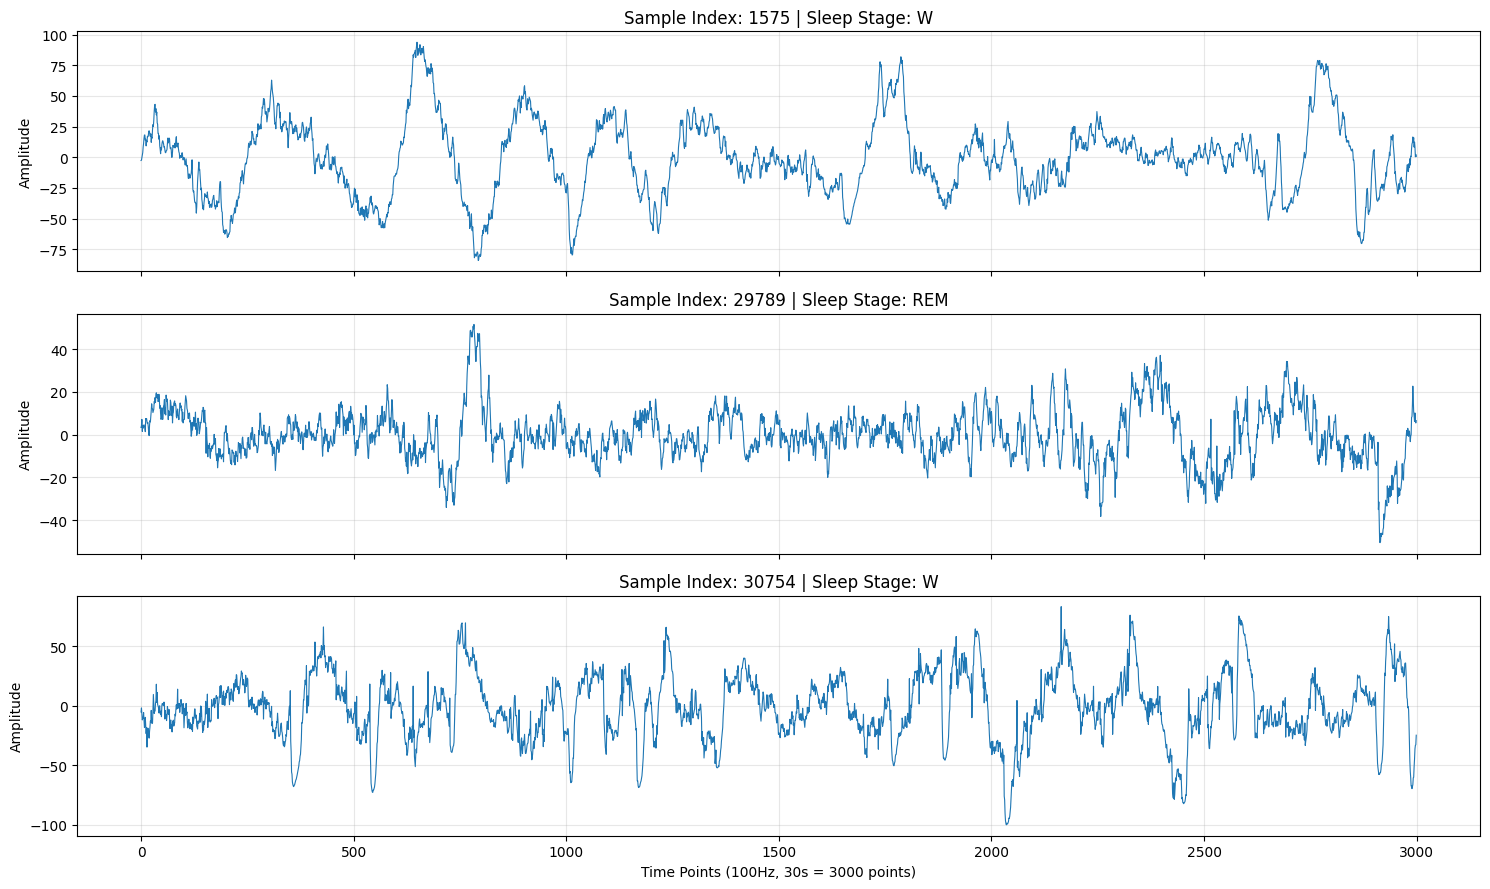

In [30]:
# --- 1. 定义睡眠阶段名称映射 ---
stage_names = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}

# --- 2. 准备数据 ---
# eeg_train_x 已经是 (Samples, 3000, 1)
# y_train 是 One-hot，需要转回类别索引
train_labels_idx = np.argmax(y_train, axis=1)

# --- 3. 修改绘图逻辑 ---
import matplotlib.pyplot as plt

def plot_eeg_samples(X, y_idx, num_samples=3):
    """
    专门为 30 秒 EEG 信号设计的可视化函数
    """
    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 3 * num_samples), sharex=True)

    # 随机选几个样本
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        signal = X[idx].flatten()
        label = stage_names[y_idx[idx]]

        axes[i].plot(signal, color='#1f77b4', linewidth=0.8)
        axes[i].set_title(f"Sample Index: {idx} | Sleep Stage: {label}", fontsize=12)
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True, alpha=0.3)

    plt.xlabel("Time Points (100Hz, 30s = 3000 points)")
    plt.tight_layout()
    plt.show()

# --- 4. 调用新函数 ---
plot_eeg_samples(X_train, train_labels_idx, num_samples=3)

# 如果你还是想尝试调用旧的函数，请确保传入的是正确的维度：
# plot_sample_signals(X_train, pd.Series(train_labels_idx).map(stage_names))

In [31]:
#  (针对 EEG Numpy 结构)
# 对应我们之前 train_test_split 划分出来的结果
eeg_test_x = X_test
eeg_test_y = y_test

print("Testing features shape:")
# 预期输出: (样本数, 3000, 1)
print(eeg_test_x.shape)

print("\nFirst 2 samples in test set (first 5 time points):")
# 查看测试集前两个 Epoch 的起始数值
print(eeg_test_x[:2, :5, 0])

print("\nTesting targets (One-hot encoded) for first 2 samples:")
# 预期输出类似: [[0. 0. 1. 0. 0.], [1. 0. 0. 0. 0.]]
print(eeg_test_y[:2])

Testing features shape:
(8207, 3000, 1)

First 2 samples in test set (first 5 time points):
[[ 3.3675213  1.017094  -5.094017  -5.940171  -6.786325 ]
 [18.523077  14.119658  14.789743   3.7811966 10.194872 ]]

Testing targets (One-hot encoded) for first 2 samples:
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]]


In [32]:
# --- (针对 EEG Numpy 结构) ---
# 注意：我们使用 eeg_train_x/y 和 eeg_test_x/y
print("--- Training Data Shapes ---")
# 这里的 X_data 对应原始加载的全量数据，类似于旧代码的 ecg_train
print("Shape of full EEG dataset (X_data):", X_data.shape)
print("Shape of eeg_train_x (features):", eeg_train_x.shape)
print("Shape of eeg_train_y (labels):", eeg_train_y.shape)

print("\n--- Testing Data Shapes ---")
print("Shape of eeg_test_x (features):", eeg_test_x.shape)
print("Shape of eeg_test_y (labels):", eeg_test_y.shape)

--- Training Data Shapes ---
Shape of full EEG dataset (X_data): (41034, 3000, 1)
Shape of eeg_train_x (features): (32827, 3000, 1)
Shape of eeg_train_y (labels): (32827, 5)

--- Testing Data Shapes ---
Shape of eeg_test_x (features): (8207, 3000, 1)
Shape of eeg_test_y (labels): (8207, 5)


### Building a CNN Model 

In [33]:
# ---  (针对 EEG) ---
# 注意 1：我们已经在前面的步骤中定义了 eeg_train_x/y
# 注意 2：睡眠分期通常为 5 分类
num_sleep_classes = 5

# 由于我们在 dp.format_for_model 中已经处理好了 Reshape 和 One-hot，
# 这里我们直接确认变量即可。如果你想保留这个函数调用以维持结构：
X_train = eeg_train_x
y_train = eeg_train_y
X_test = eeg_test_x
y_test = eeg_test_y

print("Final shapes for Model Input:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")

# 验证：EEG 的时间步长应该是 3000
if X_train.shape[1] != 3000:
    print(f"警告：检测到时间步长为 {X_train.shape[1]}，请检查是否完整包含了 30 秒信号。")

Final shapes for Model Input:
Train X: (32827, 3000, 1), Train y: (32827, 5)
Test X: (8207, 3000, 1), Test y: (8207, 5)


In [35]:
# --- 检查 Conv1D 准备后的数组形状 ---
print("--- Final EEG Shape Verification ---")
print("Shape of X_train (features):", X_train.shape)
print("Shape of y_train (labels):", y_train.shape)

print("\nShape of X_test (features):", X_test.shape)
print("Shape of y_test (labels):", y_test.shape)

# 额外的逻辑检查，确保符合睡眠分期标准
expected_timesteps = 3000  # 30秒 * 100Hz
expected_classes = 5       # W, N1, N2, N3, REM

if X_train.shape[1] == expected_timesteps:
    print(f"\n时间步长校验通过: {X_train.shape[1]} points (30s)")
else:
    print(f"\n时间步长警告: 预期 {expected_timesteps}, 实际为 {X_train.shape[1]}")

if y_train.shape[1] == expected_classes:
    print(f"类别数校验通过: {y_train.shape[1]} classes")
else:
    print(f"类别数警告: 预期 {expected_classes}, 实际为 {y_train.shape[1]}")

--- Final EEG Shape Verification ---
Shape of X_train (features): (32827, 3000, 1)
Shape of y_train (labels): (32827, 5)

Shape of X_test (features): (8207, 3000, 1)
Shape of y_test (labels): (8207, 5)

时间步长校验通过: 3000 points (30s)
类别数校验通过: 5 classes


In [37]:
# 运行这个 cell 之前请确保已经 import 了最新的 create_cnn_model
from src.model_training import create_cnn_model
model = create_cnn_model(input_shape=(3000, 1), num_classes=5)




EEG Sleep Staging Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 2951, 64)          3264      
                                                                 
 batch_normalization (Batch  (None, 2951, 64)          256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 368, 64)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 359, 128)          82048     
                                                                 
 batch_normalization_1 (Bat  (None, 359, 128)          512       
 chNormalization)                                                
                    

In [38]:
# --- 1. 引用与参数设定 ---
# 注意：确保你的 src/model_training.py 已经针对 EEG 进行了优化


# 确认输入维度为 (3000, 1)
input_shape = (X_train.shape[1], 1)
# 确认类别数为 5 (W, N1, N2, N3, REM)
num_classes = y_train.shape[1]

print(f"即将构建模型：输入形状 {input_shape}, 类别数 {num_classes}")

# --- 2. 构建模型 ---
# 建议在 create_cnn_model 内部使用较大的第一层卷积核（如 50-100），以提取低频特征
model = create_cnn_model(input_shape, num_classes)

# --- 3. 打印模型架构检查 ---
model.summary()

即将构建模型：输入形状 (3000, 1), 类别数 5
EEG Sleep Staging Model Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 2951, 64)          3264      
                                                                 
 batch_normalization_2 (Bat  (None, 2951, 64)          256       
 chNormalization)                                                
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 368, 64)           0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 359, 128)          82048     
                                                                 
 batch_normalization_3 (Bat  (None, 359, 128)          512       
 chNormalization)                                         

Epoch 1/20


821/821 [==============================] - 58s 69ms/step - loss: 0.8426 - accuracy: 0.6859 - val_loss: 0.5142 - val_accuracy: 0.8064
Epoch 2/20
821/821 [==============================] - 71s 87ms/step - loss: 0.5909 - accuracy: 0.7900 - val_loss: 0.4972 - val_accuracy: 0.8186
Epoch 3/20
821/821 [==============================] - 46s 56ms/step - loss: 0.5487 - accuracy: 0.8078 - val_loss: 0.5221 - val_accuracy: 0.7985
Epoch 4/20
821/821 [==============================] - 46s 56ms/step - loss: 0.5065 - accuracy: 0.8158 - val_loss: 0.4832 - val_accuracy: 0.8262
Epoch 5/20
821/821 [==============================] - 46s 56ms/step - loss: 0.4812 - accuracy: 0.8246 - val_loss: 0.4347 - val_accuracy: 0.8367
Epoch 6/20
821/821 [==============================] - 46s 56ms/step - loss: 0.4681 - accuracy: 0.8301 - val_loss: 0.4735 - val_accuracy: 0.8279
Epoch 7/20
821/821 [==============================] - 49s 60ms/step - loss: 0.4471 - accuracy: 0.8364 - val_loss: 0.4703 - val_accurac

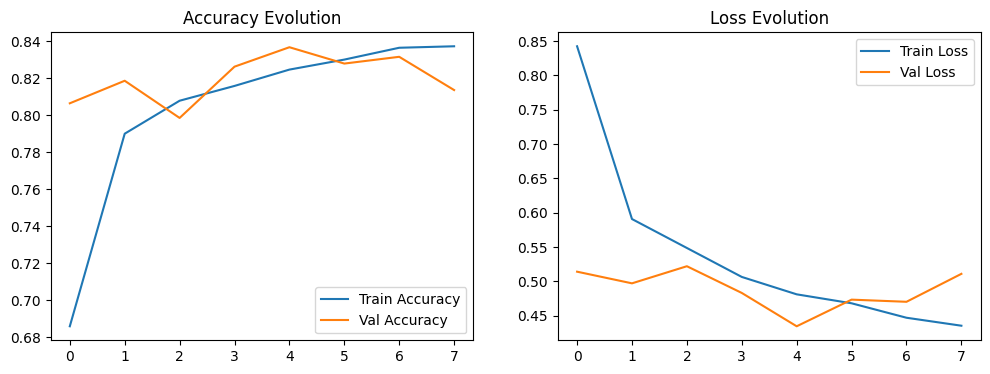

In [39]:
from tensorflow.keras.callbacks import EarlyStopping
# --- 1. 设置回调函数 ---
# 监控验证集的损失值 (val_loss)，如果连续 3 个 epoch 没有改进则停止训练
# restore_best_weights=True 确保训练结束后模型保留效果最好的那一轮参数
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# --- 2. 开始训练 ---
# 我们将 epochs 设高一点，交给 EarlyStopping 来控制何时结束
history = model.fit(
    X_train,
    y_train,
    epochs=20,           # 增加上限，靠早停机制控制
    batch_size=32,       # 保持 32，如果显存充裕可以试 64
    validation_split=0.2, # 建议从训练集中分出 20% 作为验证集
    callbacks=[early_stop],
    verbose=1
)
# --- 3. 绘制训练曲线 (可选) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()


257/257 [==============================] - 3s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           W       0.89      0.93      0.91      1582
          N1       0.69      0.05      0.09       546
          N2       0.89      0.87      0.88      3473
          N3       0.84      0.92      0.88      1129
         REM       0.69      0.88      0.78      1477

    accuracy                           0.84      8207
   macro avg       0.80      0.73      0.71      8207
weighted avg       0.84      0.84      0.82      8207



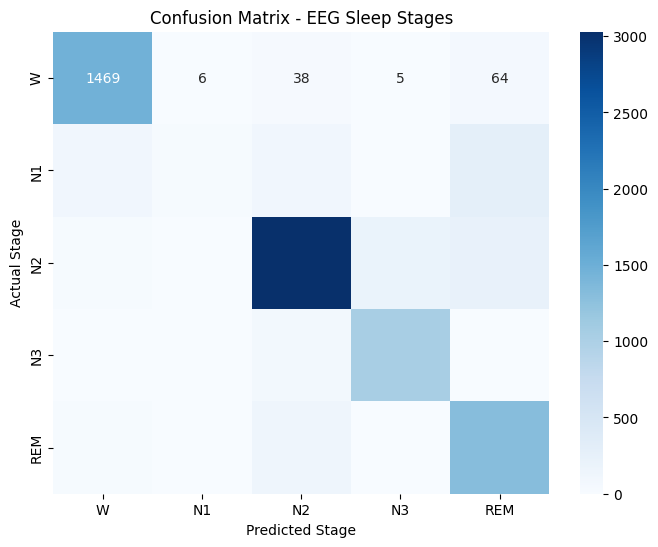

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# 1. 获取模型在测试集上的预测值
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. 定义标签名称
target_names = ['W', 'N1', 'N2', 'N3', 'REM']

# 3. 打印详细的分类报告 (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

# 4. 绘制混淆矩阵
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - EEG Sleep Stages')
plt.ylabel('Actual Stage')
plt.xlabel('Predicted Stage')
plt.show()

In [55]:
!pip install lime
!pip install --upgrade IPython
!pip install --upgrade notebook
!pip install --upgrade ipython ipywidgets

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     -------------------------------------- 139.8/139.8 kB 2.8 MB/s eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 11.6 MB/s eta 0:00:00
     ------------------------------------- 914.9/914.9 kB 28.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import os
import tensorflow as tf

# 换一个全新的名字，后缀用 .h5，这在 Windows 下更兼容
final_model_name = "eeg_final_model.h5"

try:
    model.save(final_model_name)
    print(f"✅ 模型已成功保存在当前目录: {os.path.abspath(final_model_name)}")
except Exception as e:
    print(f"❌ 依然报错: {e}")

✅ 模型已成功保存在当前目录: E:\Python\LIME-for-Time-Series\notebooks\eeg_final_model.h5


正在为样本 10 生成分段解释...
Notebook 渲染失败，改用静态绘图展示重要特征...


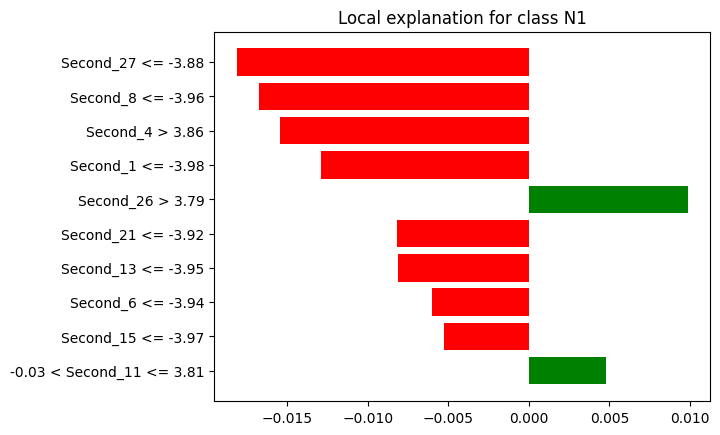

✅ 交互式解释已保存至: eeg_explanation.html


In [57]:
import numpy as np
from lime import lime_tabular
import matplotlib.pyplot as plt

# --- A. 数据降维处理（提高解释效率和可读性） ---
# 将 3000 点压缩为 30 个片段（每段 100 点，即 1 秒）
def segment_data(data):
    # 输入维度 (Samples, 3000, 1) -> (Samples, 30)
    return np.mean(data.reshape(data.shape[0], 30, 100), axis=2)

X_train_segmented = segment_data(X_train)

# --- B. 准备 LIME 解释器 ---
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_segmented, # 使用分段后的数据
    mode='classification',
    training_labels=np.argmax(y_train, axis=1),
    # 特征名称改为“秒”
    feature_names=[f"Second_{i}" for i in range(30)],
    class_names=['W', 'N1', 'N2', 'N3', 'REM'],
    discretize_continuous=True
)

# --- C. 挑选样本并定义适配函数 ---
idx = 10
sample_raw = X_test[idx] # (3000, 1)
sample_segmented = segment_data(sample_raw.reshape(1, 3000, 1)).flatten()

# 预测函数：需要把 LIME 生成的 30 维扰动数据还原回 3000 维给模型看
def predict_fn_segmented(segmented_inputs):
    # 将 (N, 30) 还原回 (N, 3000, 1)
    # 重复每个片段 100 次
    restored = np.repeat(segmented_inputs, 100, axis=1).reshape(-1, 3000, 1)
    return model.predict(restored, verbose=0)

# --- D. 运行解释 ---
print(f"正在为样本 {idx} 生成分段解释...")
exp = explainer.explain_instance(
    sample_segmented,
    predict_fn_segmented,
    num_features=10
)

# --- E. 解决展示报错的鲁棒方法 ---
try:
    # 尝试直接显示
    exp.show_in_notebook(show_table=True)
except Exception as e:
    print("Notebook 渲染失败，改用静态绘图展示重要特征...")
    # 备选方案：使用 matplotlib 绘制重要性柱状图
    exp.as_pyplot_figure()
    plt.show()
    # 同时生成一个 HTML 文件，你可以直接在文件夹里双击打开查看交互图
    exp.save_to_file('eeg_explanation.html')
    print("✅ 交互式解释已保存至: eeg_explanation.html")

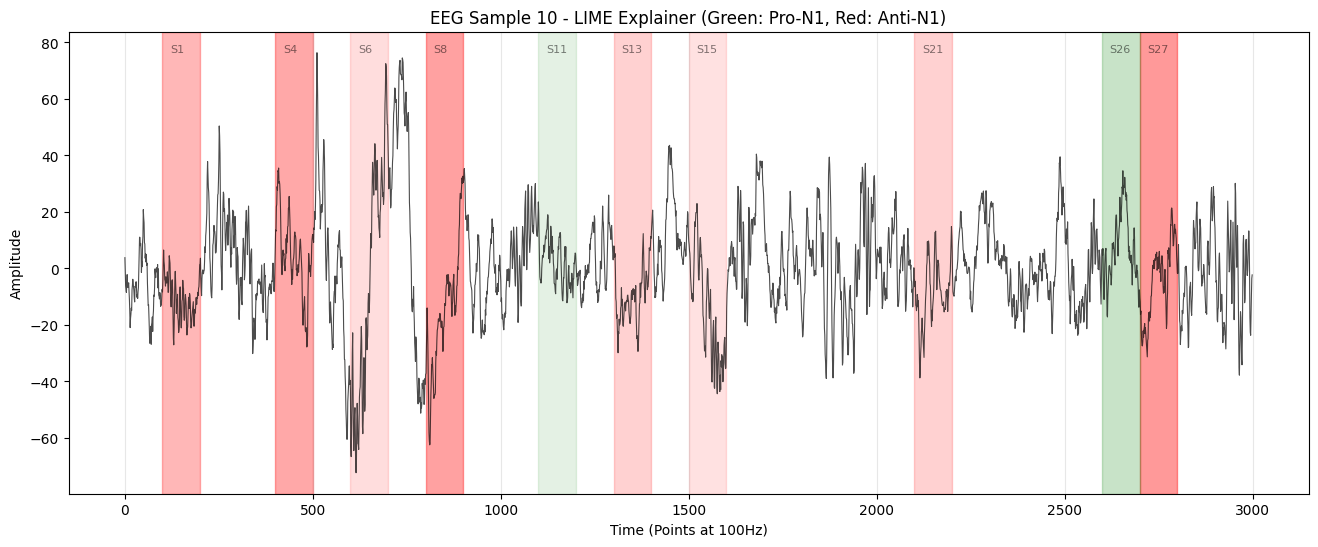

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def plot_lime_on_eeg_fixed(idx, exp, X_test_raw):
    # 1. 获取原始信号
    signal = X_test_raw[idx].flatten()

    # 2. 提取 LIME 权重
    # exp.as_list() 的格式通常是 [('Second_26 > 3.79', 0.012), ...]
    # 我们需要更精准地提取出数字 ID
    raw_weights = exp.as_list()
    weights_dict = {}
    for feature_str, weight in raw_weights:
        # 从 "Second_26 > 3.79" 中提取出 26
        try:
            sec_id = int(feature_str.split('_')[1].split(' ')[0])
            weights_dict[sec_id] = weight
        except:
            continue

    # 3. 计算权重的最大绝对值，用于归一化颜色透明度
    all_weights = [abs(w) for w in weights_dict.values()]
    max_w = max(all_weights) if all_weights else 1.0

    # 4. 绘图
    plt.figure(figsize=(16, 6))
    plt.plot(signal, color='black', linewidth=0.8, alpha=0.7, label='EEG Signal')

    # 5. 涂色逻辑
    for sec_id, weight in weights_dict.items():
        start_idx = sec_id * 100
        end_idx = (sec_id + 1) * 100

        # 颜色：绿色代表支持该分类，红色代表反对
        color = 'green' if weight > 0 else 'red'

        # 这里的 alpha 设置为相对于最大权重的比例，确保最显著的部分颜色最深
        normalized_alpha = (abs(weight) / max_w) * 0.4

        plt.axvspan(start_idx, end_idx, color=color, alpha=normalized_alpha)
        # 在顶部标注一下秒数
        plt.text(start_idx + 20, max(signal), f"S{sec_id}", fontsize=8, alpha=0.5)

    plt.title(f"EEG Sample {idx} - LIME Explainer (Green: Pro-N1, Red: Anti-N1)")
    plt.xlabel("Time (Points at 100Hz)")
    plt.ylabel("Amplitude")
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# 重新运行绘图
plot_lime_on_eeg_fixed(idx=10, exp=exp, X_test_raw=X_test)

### LIME for Time Seris Domain

#### Step 1) Select an instance for explanation and predict its class

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# 定义清晰版绘图函数
def plot_clean_eeg_explanation(idx, exp, X_test_raw, label_idx, prob, class_names):
    signal = X_test_raw[idx].flatten()

    # 获取对应标签的权重列表，处理可能存在的索引类型问题
    try:
        raw_weights = exp.as_list(label=label_idx)
    except (KeyError, TypeError):
        # 如果传入的是字符串，尝试转换回索引
        available_labels = exp.available_labels()
        raw_weights = exp.as_list(label=available_labels[0])

    weights_dict = {int(f.split('_')[1].split(' ')[0]): w for f, w in raw_weights}

    # 创建纯白画布
    plt.figure(figsize=(16, 6), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # 绘制波形：纯黑色高对比度
    plt.plot(signal, color='black', linewidth=1.2, alpha=0.8)

    if weights_dict:
        max_w = max([abs(w) for w in weights_dict.values()])
        for sec_id, weight in weights_dict.items():
            start, end = sec_id * 100, (sec_id + 1) * 100
            color = 'green' if weight > 0 else 'red'
            plt.axvspan(start, end, color=color, alpha=(abs(weight)/max_w) * 0.5)
            # 标注文字
            plt.text(start + 5, max(signal) * 0.8, f"S{sec_id}",
                     color='blue', fontsize=9, fontweight='bold')

    # 获取当前类名
    curr_label = class_names[label_idx] if isinstance(label_idx, int) else label_idx
    plt.title(f"LIME Heatmap: {curr_label} (Prob: {prob:.4f})", fontsize=15)
    plt.xlabel("Time Points (100Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

所有类别的置信度排名: [2 4 1 3 0]
最终判定类别: N2 (Index: 2)


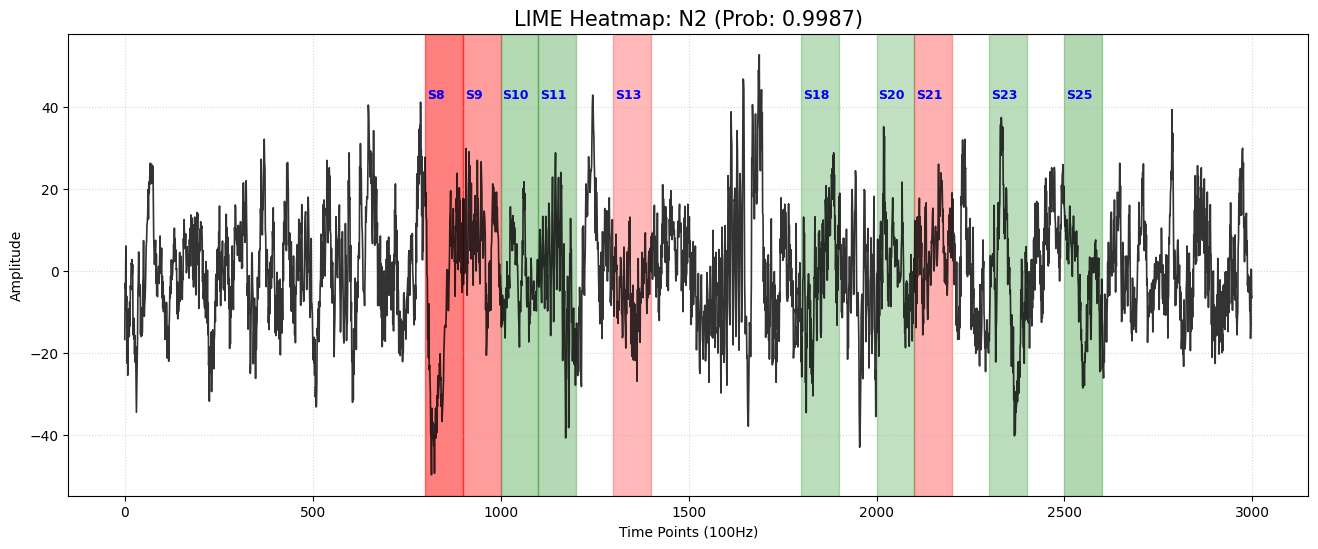

In [78]:
# 1. 设置标签
class_labels = ['W', 'N1', 'N2', 'N3', 'REM']

# 2. 调用分析函数
from src.lime_explanation import analyze_prediction
top_pred_classes, predicted_val = analyze_prediction(probability_vector, class_labels)

# --- 核心修复逻辑：自动兼容索引或字符串 ---
if isinstance(predicted_val, str):
    # 如果返回的是字符串，反推它的索引
    predicted_class_name = predicted_val
    predicted_class_idx = class_labels.index(predicted_val)
else:
    # 如果返回的是数字，直接索引
    predicted_class_idx = int(predicted_val)
    predicted_class_name = class_labels[predicted_class_idx]

print(f"所有类别的置信度排名: {top_pred_classes}")
print(f"最终判定类别: {predicted_class_name} (Index: {predicted_class_idx})")

# --- 3. 执行绘图 ---
# 确保 probability_vector[0][predicted_class_idx] 获取的是数值
current_prob = probability_vector[0][predicted_class_idx]

plot_clean_eeg_explanation(
    id_eeg,
    exp,
    X_test,
    predicted_class_idx,
    current_prob,
    class_labels
)